In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import datetime

In [47]:
cities = pd.read_csv('..//data//Cities.csv')
display(cities)
concierge = pd.read_csv(
    '..//data//concierge.csv',
    dtype={
        'ID клиента': str,
        'Номер задачи': str,
        'Номер кейса': str
    },
    parse_dates=['Дата и время создания (МСК)'],
    dayfirst=True
 )
display(concierge)

,Unnamed: 0,City,Client_ID
0,0,Amalfi,2
1,1,Grimaud,1
2,2,Phalombe,5
3,3,Абинск,2
4,4,Абу-Даби,3
...,...,...,...
365,365,Южноуральск,1
366,366,Якутск,26
367,367,Ялта,1
368,368,Ярославль,128


,Номер кейса,Номер задачи,ID клиента,Пол,Канал обращения,Ответственный отдел,Категория услуг,Услуга,Программа,Дата и время создания (МСК),Что делали,Страна,Город,"""Технический кейс"""
0,32737,32737.1,19070,NaN,Телефон,Первая Линия,Информационная поддержка,Информационный запрос,Базовый,2024-11-30 21:39:00,"Инфо, Подборка",Россия,Курск,0
1,32646,32646.1,19067,NaN,Мессенджер,Лайфстайл,Товары,Цветы,Базовый,2024-11-30 15:25:00,NaN,Россия,Воронеж,0
2,32583,32583.1,19066,NaN,Мессенджер,Первая Линия,Информационная поддержка,Консьерж программа,Базовый,2024-11-30 07:15:00,Инфо,Россия,Москва,1
3,32571,32571.1,19065,NaN,Мессенджер,Первая Линия,Сервисы,Бесплатная юридическая консультация,Базовый,2024-11-29 23:15:00,Передано партнеру,Россия,Владимир,0
4,32572,32572.1,19065,NaN,Мессенджер,Первая Линия,Информационная поддержка,Информационный запрос,Базовый,2024-11-29 23:30:00,Инфо,Россия,Владимир,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33108,922,NaN,NaN,NaN,NaN,NaN,Путешествия,Авиа,NaN,NaT,NaN,Турция,Анталия,0
33109,921,NaN,NaN,NaN,NaN,NaN,Размещение,Отели,NaN,NaT,NaN,Турция,Анталия,0
33110,920,NaN,NaN,NaN,NaN,NaN,Размещение,Отели,NaN,NaT,NaN,Турция,Бодрум,0
33111,764,NaN,NaN,NaN,NaN,NaN,Мероприятия,Мероприятия,NaN,NaT,NaN,Италия,Лаятико,0


In [48]:
concierge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33113 entries, 0 to 33112
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Номер кейса                  33113 non-null  object        
 1   Номер задачи                 32728 non-null  object        
 2   ID клиента                   32728 non-null  object        
 3   Пол                          11522 non-null  object        
 4   Канал обращения              31681 non-null  object        
 5   Ответственный отдел          31681 non-null  object        
 6   Категория услуг              33113 non-null  object        
 7   Услуга                       33113 non-null  object        
 8   Программа                    29806 non-null  object        
 9   Дата и время создания (МСК)  32728 non-null  datetime64[ns]
 10  Что делали                   30456 non-null  object        
 11  Страна                       32765 non-nu

In [49]:
concierge.describe()

,Дата и время создания (МСК),"""Технический кейс"""
count,32728,33113.000000
mean,2024-09-07 04:27:26.921902080,0.079606
min,2024-04-01 12:14:00,0.000000
25%,2024-07-29 14:17:45,0.000000
50%,2024-09-12 20:37:00,0.000000
75%,2024-10-24 07:37:30,0.000000
max,2024-11-30 23:13:00,1.000000
std,NaN,0.270687


In [50]:
display(concierge['ID клиента'].nunique())
display(concierge['ID клиента'].isna().sum())

5516

np.int64(385)

In [51]:
display(concierge['Номер кейса'].nunique())
display(concierge['Номер кейса'].isna().sum())

24622

np.int64(0)

In [52]:
display(concierge.duplicated().sum())
display(concierge['Номер кейса'].duplicated().sum())
display(concierge['ID клиента'].duplicated().sum())

np.int64(0)

np.int64(8491)

np.int64(27596)

In [53]:
df_us = pd.DataFrame(concierge['Услуга'].unique(), columns=['Услуга'])
display(df_us.sort_values(by='Услуга').reset_index(drop=True).head(40))

,Услуга
0,Авиа
1,Авто
2,Автобусы
3,Алкоголь
4,Аренда транспорта без водителя
5,Аренда транспорта с водителем
6,Афиша
7,Базы отдыха
8,Банкет
9,Бесплатная медицинская консультация


In [54]:
# 1) Впиши сюда 3 ID клиентов, которых считаем высокомаржинальными
high_value_client_ids = ['112', '475', '190']  # TODO: замени на свои ID

# Базовая подготовка
df = concierge.copy()
df['ID клиента'] = df['ID клиента'].astype('string').str.strip()
df = df[df['ID клиента'].notna() & (df['ID клиента'] != '')].copy()

# Флаг информационного запроса
is_info = (
    df['Услуга'].fillna('').str.strip().eq('Информационный запрос')
    | df['Категория услуг'].fillna('').str.contains('Информац', case=False, na=False)
    | df['Что делали'].fillna('').str.contains('Инфо', case=False, na=False)
)
df['is_info'] = is_info.astype(int)

# Отдельные датафреймы
df_top_clients = df[df['ID клиента'].isin(high_value_client_ids)].copy()
df_other_clients = df[~df['ID клиента'].isin(high_value_client_ids)].copy()

print('rows top clients:', len(df_top_clients))
print('rows other clients:', len(df_other_clients))
display(df_top_clients.head(30))

rows top clients: 437
rows other clients: 32291


,Номер кейса,Номер задачи,ID клиента,Пол,Канал обращения,Ответственный отдел,Категория услуг,Услуга,Программа,Дата и время создания (МСК),Что делали,Страна,Город,"""Технический кейс""",is_info
26120,1852,1852.2772,475,NaN,NaN,NaN,Путешествия,ВИП обслуживание в аэропорту,VIP,2024-05-06 16:20:00,NaN,Россия,Москва,0,0
26121,1856,1856.2776,475,NaN,NaN,NaN,Путешествия,ВИП обслуживание в аэропорту,VIP,2024-05-06 19:10:00,NaN,Россия,Москва,0,0
26122,1938,1938.2890,475,NaN,NaN,NaN,Путешествия,ВИП обслуживание в аэропорту,VIP,2024-05-10 16:17:00,NaN,Россия,Москва,0,0
26123,2193,2193.3204,475,NaN,NaN,NaN,Размещение,Отели,VIP,2024-05-16 21:41:00,NaN,Турция,Стамбул,0,0
26124,2193,2193.3270,475,NaN,NaN,NaN,Путешествия,Трансфер,VIP,2024-05-18 10:26:00,NaN,NaN,NaN,0,0
26125,2349,2349.3385,475,NaN,NaN,NaN,Путешествия,ВИП обслуживание в аэропорту,VIP,2024-05-20 20:39:00,NaN,Россия,Москва,0,0
26126,2570,2570.3677,475,NaN,NaN,NaN,Путешествия,ВИП обслуживание в аэропорту,VIP,2024-05-24 15:54:00,NaN,Объединенные Арабские Эмираты,"ОАЭ, Dubai, Дубай",0,0
26127,2598,2598.3706,475,NaN,NaN,NaN,Путешествия,Регистрация на рейс,VIP,2024-05-25 11:09:00,NaN,NaN,NaN,0,0
26128,2631,2631.3745,475,NaN,NaN,NaN,Путешествия,Авиа,VIP,2024-05-27 01:57:00,NaN,NaN,NaN,0,0
26129,2677,2677.3831,475,NaN,NaN,NaN,Путешествия,ВИП обслуживание в аэропорту,VIP,2024-05-28 03:25:00,NaN,Россия,Москва,0,0


In [55]:
def compare_clients(df_all, top_ids):
    data = df_all.copy()
    data['is_top'] = data['ID клиента'].isin(top_ids).astype(int)

    by_client = (
        data.groupby('ID клиента', dropna=False)
        .agg(
            requests=('ID клиента', 'size'),
            info_requests=('is_info', 'sum'),
            unique_services=('Услуга', 'nunique'),
            unique_categories=('Категория услуг', 'nunique'),
            messenger_share=('Канал обращения', lambda s: (s == 'Мессенджер').mean()),
            phone_share=('Канал обращения', lambda s: (s == 'Телефон').mean()),
            top_program_share=('Программа', lambda s: s.fillna('').str.contains('Прем|VIP|Преми|Private', case=False).mean())
        )
        .reset_index()
    )
    by_client['non_info_requests'] = by_client['requests'] - by_client['info_requests']
    by_client['info_share'] = by_client['info_requests'] / by_client['requests']
    by_client['non_info_share'] = 1 - by_client['info_share']
    by_client['is_top'] = by_client['ID клиента'].isin(top_ids).astype(int)

    summary = by_client.groupby('is_top').agg(
        clients=('ID клиента', 'nunique'),
        median_requests=('requests', 'median'),
        median_info_share=('info_share', 'median'),
        median_non_info_share=('non_info_share', 'median'),
        median_unique_services=('unique_services', 'median'),
        median_unique_categories=('unique_categories', 'median')
    )

    corr_cols = [
        'requests', 'info_requests', 'info_share', 'non_info_share',
        'unique_services', 'unique_categories', 'messenger_share', 'phone_share', 'top_program_share', 'is_top'
    ]
    corr = by_client[corr_cols].corr(numeric_only=True)['is_top'].sort_values(ascending=False)

    return by_client, summary, corr

by_client, summary, corr_to_top = compare_clients(df, high_value_client_ids)

print('Сравнение: 0 = остальные, 1 = топ-3')
display(summary)
print('Корреляция признаков с принадлежностью к топ-3:')
display(corr_to_top)

Сравнение: 0 = остальные, 1 = топ-3


,clients,median_requests,median_info_share,median_non_info_share,median_unique_services,median_unique_categories
is_top,,,,,,
0,5513,2.0,0.750000,0.250000,2.0,2.0
1,3,124.0,0.379032,0.620968,22.0,7.0


Корреляция признаков с принадлежностью к топ-3:


is_top               1.000000
requests             0.201035
unique_services      0.138903
info_requests        0.133296
unique_categories    0.067426
top_program_share    0.031387
non_info_share       0.017455
messenger_share      0.012044
info_share          -0.017455
phone_share         -0.017536
Name: is_top, dtype: float64

In [56]:
# Какие инфо-запросы можно убрать первыми (в целом и в топ-3)
info_col = df[df['is_info'] == 1]

automation_candidates = (
    info_col.groupby(['Категория услуг', 'Услуга'], dropna=False)
    .size()
    .reset_index(name='volume')
    .sort_values('volume', ascending=False)
    .head(15)
)

top_info_candidates = (
    df_top_clients[df_top_clients['is_info'] == 1]
    .groupby(['Категория услуг', 'Услуга'], dropna=False)
    .size()
    .reset_index(name='volume_top3')
    .sort_values('volume_top3', ascending=False)
    .head(15)
)

print('Топ-15 инфо-запросов для автоматизации (все клиенты):')
display(automation_candidates)

print('Топ-15 инфо-запросов у топ-3 клиентов:')
display(top_info_candidates)

# Простая оценка эффекта: если автоматизируем X% инфо-запросов
automation_rate = 0.30  # 30%
total_info = int(df['is_info'].sum())
saved_requests = int(total_info * automation_rate)
print(f'Если автоматизировать {automation_rate:.0%} инфо-запросов, можно разгрузить ~{saved_requests} обращений.')

Топ-15 инфо-запросов для автоматизации (все клиенты):


,Категория услуг,Услуга,volume
8,Информационная поддержка,Информационный запрос,2849
9,Информационная поддержка,Консьерж программа,2683
7,Гастро,Ресторан,1764
52,Размещение,Отели,1370
26,Путешествия,Авиа,1209
45,Путешествия,Регистрация на рейс,864
64,Сервисы,Сервисы,580
79,Товары,Товары,517
47,Путешествия,Трансфер,463
23,Мероприятия,Представления,435


Топ-15 инфо-запросов у топ-3 клиентов:


,Категория услуг,Услуга,volume_top3
11,Путешествия,ВИП обслуживание в аэропорту,21
19,Путешествия,Регистрация на рейс,20
4,Информационная поддержка,Информационный запрос,16
10,Путешествия,Авиа,15
32,Товары,Товары,14
20,Путешествия,Трансфер,9
3,Гастро,Ресторан,7
6,Информационная поддержка,Предложения от КС,6
22,Размещение,Отели,6
28,Сервисы,Сервисы,6


Если автоматизировать 30% инфо-запросов, можно разгрузить ~5576 обращений.


In [57]:
# Приоритизация: что автоматизировать первым
all_info = df[df['is_info'] == 1]
top_info = df_top_clients[df_top_clients['is_info'] == 1]

all_by_service = (
    all_info.groupby(['Категория услуг', 'Услуга'], dropna=False)
    .size()
    .rename('volume_all')
    .reset_index()
 )

top_by_service = (
    top_info.groupby(['Категория услуг', 'Услуга'], dropna=False)
    .size()
    .rename('volume_top')
    .reset_index()
 )

priority = all_by_service.merge(top_by_service, on=['Категория услуг', 'Услуга'], how='left')
priority['volume_top'] = priority['volume_top'].fillna(0)
priority['top_share'] = np.where(priority['volume_all'] > 0, priority['volume_top'] / priority['volume_all'], 0)

# Score: большой общий объем + присутствие у топ-клиентов
priority['priority_score'] = priority['volume_all'] * (1 + 2 * priority['top_share'])
priority = priority.sort_values('priority_score', ascending=False).reset_index(drop=True)

display(priority.head(20))

,Категория услуг,Услуга,volume_all,volume_top,top_share,priority_score
0,Информационная поддержка,Информационный запрос,2849,16.0,0.005616,2881.0
1,Информационная поддержка,Консьерж программа,2683,0.0,0.000000,2683.0
2,Гастро,Ресторан,1764,7.0,0.003968,1778.0
3,Размещение,Отели,1370,6.0,0.004380,1382.0
4,Путешествия,Авиа,1209,15.0,0.012407,1239.0
5,Путешествия,Регистрация на рейс,864,20.0,0.023148,904.0
6,Сервисы,Сервисы,580,6.0,0.010345,592.0
7,Товары,Товары,517,14.0,0.027079,545.0
8,Путешествия,Трансфер,463,9.0,0.019438,481.0
9,Мероприятия,Представления,435,2.0,0.004598,439.0


## Funnel from the `What was done` column

The `What was done` field can be treated as a set of deal stages inside a case. In this model, one `case number` is one deal, and tasks/rows inside the case are touches or operations.

Important limitation: this is not a perfect linear funnel. The field may contain several actions separated by commas, action order inside one row is unknown, and some cases go directly to booking/purchase without a selection step. So below we build a case-level funnel by reached stages plus a final case outcome.

In [58]:
# Parse the "What was done" field as case/deal stages.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Column names are selected by position to keep this cell robust to shell/notebook encoding issues.
if 'concierge' not in globals():
    concierge = pd.read_csv(
        '..//data//concierge.csv',
        dtype={0: str, 1: str, 2: str},
        parse_dates=[9],
        dayfirst=True
    )

COL_CASE = concierge.columns[0]
COL_TASK = concierge.columns[1]
COL_CLIENT = concierge.columns[2]
COL_CATEGORY = concierge.columns[6]
COL_SERVICE = concierge.columns[7]
COL_DATE = concierge.columns[9]
COL_WHAT = concierge.columns[10]

INFO = "\u0418\u043d\u0444\u043e".encode().decode('unicode_escape')
SELECTION = "\u041f\u043e\u0434\u0431\u043e\u0440\u043a\u0430".encode().decode('unicode_escape')
BOOKING = "\u0411\u0440\u043e\u043d\u0438\u0440\u043e\u0432\u0430\u043d\u0438\u0435/\u043f\u043e\u043a\u0443\u043f\u043a\u0430".encode().decode('unicode_escape')
PARTNER = "\u041f\u0435\u0440\u0435\u0434\u0430\u043d\u043e \u043f\u0430\u0440\u0442\u043d\u0435\u0440\u0443".encode().decode('unicode_escape')
CANCEL = "\u0421\u043d\u044f\u043b \u0437\u0430\u043f\u0440\u043e\u0441".encode().decode('unicode_escape')

funnel_actions = [INFO, SELECTION, BOOKING, PARTNER, CANCEL]

def split_actions(value):
    if pd.isna(value):
        return []
    return [x.strip() for x in str(value).split(',') if x.strip()]

funnel_rows = concierge.copy()
funnel_rows['actions_list'] = funnel_rows[COL_WHAT].apply(split_actions)

row_actions = (
    funnel_rows[[COL_CASE, COL_TASK, COL_CATEGORY, COL_SERVICE, 'actions_list']]
    .explode('actions_list')
    .rename(columns={'actions_list': 'action'})
)
row_actions = row_actions[row_actions['action'].notna() & (row_actions['action'] != '')]

action_counts = (
    row_actions['action']
    .value_counts()
    .rename_axis('action')
    .reset_index(name='rows_mentions')
)

display(action_counts)

case_funnel = (
    funnel_rows
    .groupby(COL_CASE, dropna=False)
    .agg(
        tasks=(COL_TASK, 'nunique'),
        client_id=(COL_CLIENT, 'first'),
        first_dt=(COL_DATE, 'min'),
        last_dt=(COL_DATE, 'max'),
        category=(COL_CATEGORY, lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan),
        service=(COL_SERVICE, lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan),
        actions_text=(COL_WHAT, lambda s: ', '.join(s.dropna().astype(str)))
    )
    .reset_index()
)

for action in funnel_actions:
    case_funnel[action] = case_funnel['actions_text'].str.contains(action, regex=False, na=False)

case_funnel['no_action'] = ~case_funnel[funnel_actions].any(axis=1)

case_funnel.head()

,action,rows_mentions
0,Инфо,18066
1,Бронирование/покупка,8915
2,Подборка,8118
3,Передано партнеру,2151
4,Снял запрос,589


,Номер кейса,tasks,client_id,first_dt,last_dt,category,service,actions_text,ÐÐ½ÑÐ¾,ÐÐ¾Ð´Ð±Ð¾ÑÐºÐ°,ÐÑÐ¾Ð½Ð¸ÑÐ¾Ð²Ð°Ð½Ð¸Ðµ/Ð¿Ð¾ÐºÑÐ¿ÐºÐ°,ÐÐµÑÐµÐ´Ð°Ð½Ð¾ Ð¿Ð°ÑÑÐ½ÐµÑÑ,Ð¡Ð½ÑÐ» Ð·Ð°Ð¿ÑÐ¾Ñ,no_action
0,1000,1,215,2024-04-07 11:16:00,2024-04-07 11:16:00,Мероприятия,Афиша,,False,False,False,False,False,True
1,10000,1,13605,2024-08-02 15:04:00,2024-08-02 15:04:00,Гастро,Ресторан,Инфо,False,False,False,False,False,True
2,10001,1,10257,2024-08-02 15:12:00,2024-08-02 15:12:00,Сервисы,Сервисы,Инфо,False,False,False,False,False,True
3,10002,1,13606,2024-08-02 15:26:00,2024-08-02 15:26:00,Размещение,Пакетный тур,"Инфо, Передано партнеру",False,False,False,False,False,True
4,10005,1,7524,2024-08-02 15:30:00,2024-08-02 15:30:00,Информационная поддержка,Консьерж программа,Инфо,False,False,False,False,False,True


,stage,cases,share_of_all_cases,conversion_from_previous_row
0,All cases,24622,100.0%,nan%
1,Has action in field,0,0.0%,0.0%
2,ÐÐ½ÑÐ¾,0,0.0%,nan%
3,ÐÐ¾Ð´Ð±Ð¾ÑÐºÐ°,0,0.0%,nan%
4,ÐÑÐ¾Ð½Ð¸ÑÐ¾Ð²Ð°Ð½Ð¸Ðµ/Ð¿Ð¾ÐºÑÐ¿ÐºÐ°,0,0.0%,nan%
5,ÐÐµÑÐµÐ´Ð°Ð½Ð¾ Ð¿Ð°ÑÑÐ½ÐµÑÑ,0,0.0%,nan%
6,Ð¡Ð½ÑÐ» Ð·Ð°Ð¿ÑÐ¾Ñ,0,0.0%,nan%


c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 152 (\x98) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 132 (\x84) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing fro

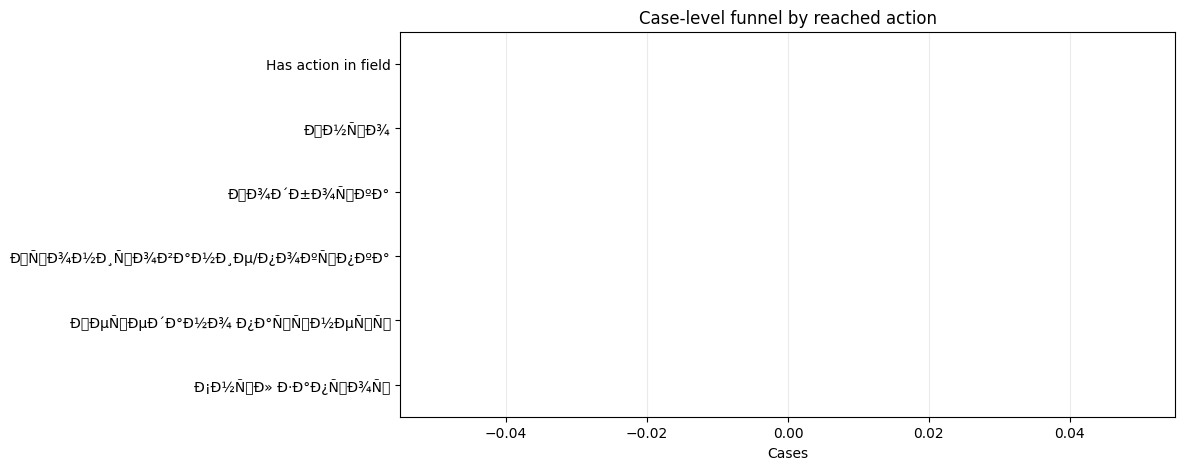

In [59]:
# Funnel by reached stages.
# This is "stage reached", not a strict sequence, because cases may skip steps.
funnel_summary = pd.DataFrame({
    'stage': [
        'All cases',
        'Has action in field',
        INFO,
        SELECTION,
        BOOKING,
        PARTNER,
        CANCEL
    ],
    'cases': [
        len(case_funnel),
        (~case_funnel['no_action']).sum(),
        case_funnel[INFO].sum(),
        case_funnel[SELECTION].sum(),
        case_funnel[BOOKING].sum(),
        case_funnel[PARTNER].sum(),
        case_funnel[CANCEL].sum()
    ]
})
funnel_summary['share_of_all_cases'] = funnel_summary['cases'] / len(case_funnel)
funnel_summary['conversion_from_previous_row'] = funnel_summary['cases'] / funnel_summary['cases'].shift(1)

display(
    funnel_summary.style.format({
        'share_of_all_cases': '{:.1%}',
        'conversion_from_previous_row': '{:.1%}'
    })
)

plt.figure(figsize=(10, 5))
sns.barplot(data=funnel_summary.iloc[1:], x='cases', y='stage', color='#4C78A8')
plt.title('Case-level funnel by reached action')
plt.xlabel('Cases')
plt.ylabel('')
plt.grid(axis='x', alpha=0.25)
plt.show()

,outcome,cases,share
0,No action,24622,100.0%


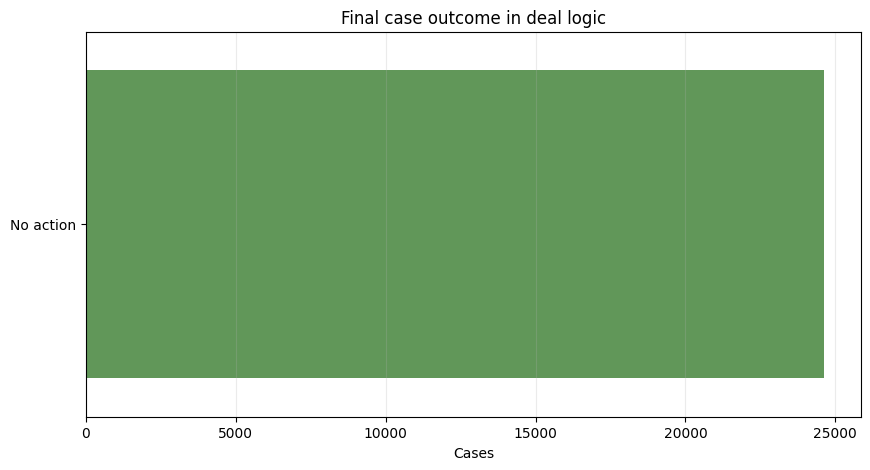

In [60]:
# Final case classification as a deal outcome.
# Priority: cancellation = lost; booking/purchase = success; then handoff/selection/info.
case_funnel['outcome'] = np.select(
    [
        case_funnel[CANCEL],
        case_funnel[BOOKING],
        case_funnel[PARTNER],
        case_funnel[SELECTION],
        case_funnel[INFO],
        case_funnel['no_action']
    ],
    [
        'Lost: request cancelled',
        'Success: booking/purchase',
        'Transferred to partner',
        'Selection without purchase',
        'Info only',
        'No action'
    ],
    default='Other'
)

outcome_summary = (
    case_funnel['outcome']
    .value_counts()
    .rename_axis('outcome')
    .reset_index(name='cases')
)
outcome_summary['share'] = outcome_summary['cases'] / len(case_funnel)
display(outcome_summary.style.format({'share': '{:.1%}'}))

plt.figure(figsize=(10, 5))
sns.barplot(data=outcome_summary, x='cases', y='outcome', color='#59A14F')
plt.title('Final case outcome in deal logic')
plt.xlabel('Cases')
plt.ylabel('')
plt.grid(axis='x', alpha=0.25)
plt.show()

,cases,info,selection,booking,partner,lost,info_rate,selection_rate,booking_rate,partner_rate,lost_rate
category,,,,,,,,,,,
Гастро,6364,0,0,0,0,0,0.0%,0.0%,0.0%,0.0%,0.0%
Информационная поддержка,5509,0,0,0,0,0,0.0%,0.0%,0.0%,0.0%,0.0%
Путешествия,3841,0,0,0,0,0,0.0%,0.0%,0.0%,0.0%,0.0%
Сервисы,3612,0,0,0,0,0,0.0%,0.0%,0.0%,0.0%,0.0%
Размещение,2067,0,0,0,0,0,0.0%,0.0%,0.0%,0.0%,0.0%
Мероприятия,1759,0,0,0,0,0,0.0%,0.0%,0.0%,0.0%,0.0%
Товары,1431,0,0,0,0,0,0.0%,0.0%,0.0%,0.0%,0.0%
Технические вопросы,39,0,0,0,0,0,0.0%,0.0%,0.0%,0.0%,0.0%


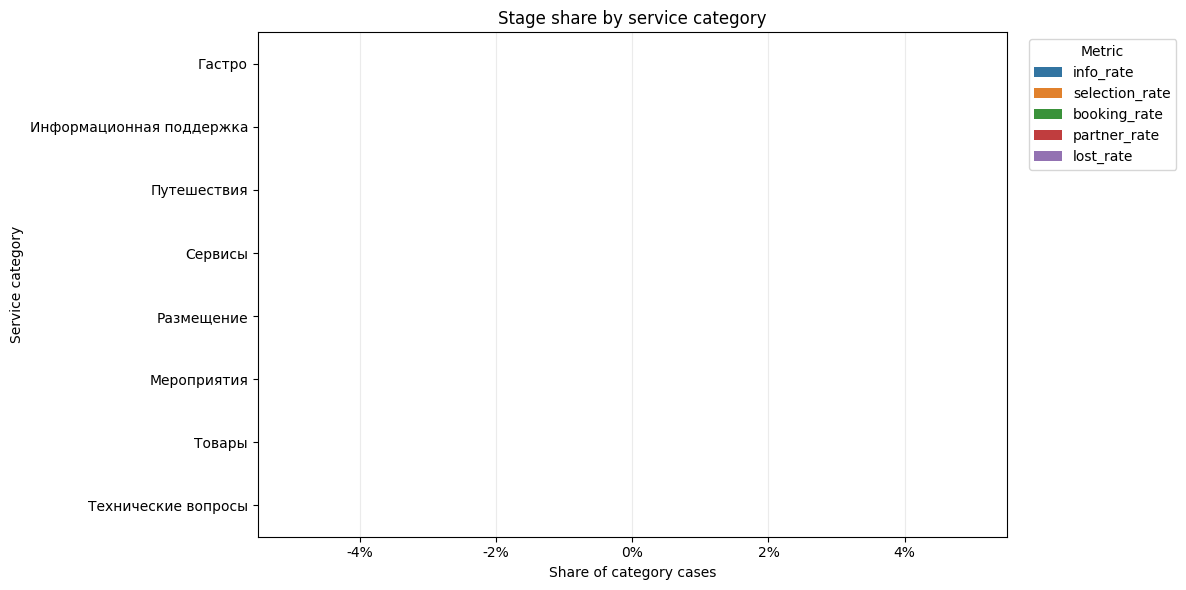

In [61]:
# Categories where the funnel behaves like sales vs service/information.
category_funnel = (
    case_funnel
    .groupby('category', dropna=False)
    .agg(
        cases=(COL_CASE, 'count'),
        info=(INFO, 'sum'),
        selection=(SELECTION, 'sum'),
        booking=(BOOKING, 'sum'),
        partner=(PARTNER, 'sum'),
        lost=(CANCEL, 'sum')
    )
    .sort_values('cases', ascending=False)
)

for col in ['info', 'selection', 'booking', 'partner', 'lost']:
    category_funnel[f'{col}_rate'] = category_funnel[col] / category_funnel['cases']

display(
    category_funnel.style.format({
        'info_rate': '{:.1%}',
        'selection_rate': '{:.1%}',
        'booking_rate': '{:.1%}',
        'partner_rate': '{:.1%}',
        'lost_rate': '{:.1%}'
    })
)

category_plot = category_funnel.reset_index().melt(
    id_vars=['category', 'cases'],
    value_vars=['info_rate', 'selection_rate', 'booking_rate', 'partner_rate', 'lost_rate'],
    var_name='metric',
    value_name='rate'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_plot, x='rate', y='category', hue='metric')
plt.title('Stage share by service category')
plt.xlabel('Share of category cases')
plt.ylabel('Service category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0%}'))
plt.grid(axis='x', alpha=0.25)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpretation

Yes, this can be presented as a funnel if `case number` is treated as a deal. The more precise name is a reached-stage funnel, not a strict sequential funnel.

Suggested logic: all cases -> info -> selection -> booking/purchase. `Transferred to partner` is better treated as a separate operational outcome/handoff, and `request cancelled` as a lost outcome.

Why it is not perfect: booking/purchase appears in more cases than selection, so some cases skip the selection step. That is normal for CRM-style data; use the `outcome` table together with the funnel.